Training on device: cuda
Weights loaded from best_dqn_cartpole.pth
Training DQN Agent...


100%|██████████| 500/500 [02:39<00:00,  3.14it/s]


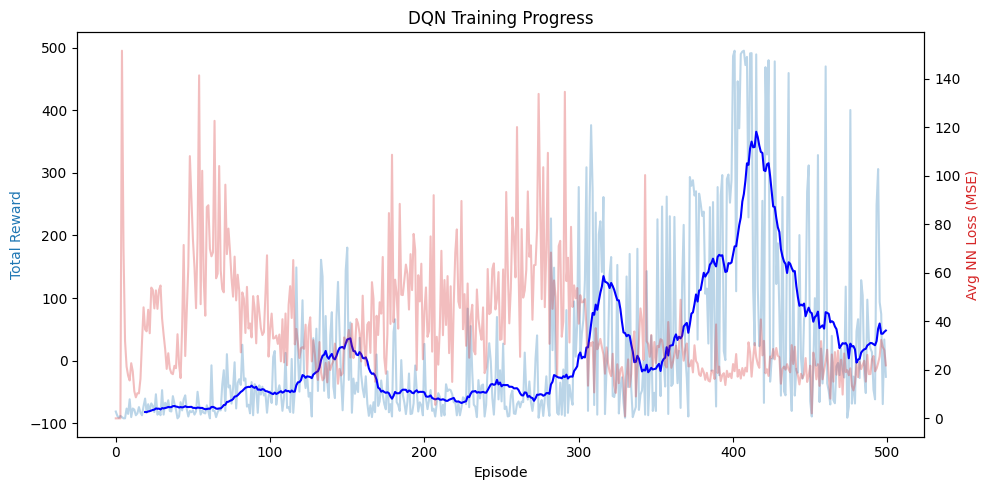

Weights loaded from best_dqn_cartpole.pth
Recording 10 episodes to dqn.mp4...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Finished Episode 1 with Score: 398.0948181152344
Finished Episode 2 with Score: 394.6473388671875
Finished Episode 3 with Score: 398.18157958984375
Finished Episode 4 with Score: 396.4217224121094
Finished Episode 5 with Score: 398.2922668457031
Finished Episode 6 with Score: 398.31573486328125
Finished Episode 7 with Score: 398.0742492675781
Finished Episode 8 with Score: 398.4143371582031
Finished Episode 9 with Score: 398.47137451171875
Finished Episode 10 with Score: 398.2359619140625
Video saved as dqn.mp4


In [10]:
import numpy as np
import gymnasium as gym
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 1. Define the Neural Network Architecture
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        # A simple Multi-Layer Perceptron (MLP)
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# 2. The Main DQN Agent
class DQNCartPole:
    def __init__(self, epsilon_init=1.0, epsilon_decay=0.995, min_epsilon=0.01, 
                 lr=1e-3, gamma=0.99, batch_size=64, buffer_size=10000, target_update_freq=10):
        self.env = gym.make('CartPole-v1')
        self.state_size = self.env.observation_space.shape[0] # 4 for CartPole
        self.action_size = self.env.action_space.n            # 2 for CartPole
        
        # Hyperparameters
        self.epsilon = epsilon_init
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        
        # Device configuration (use GPU if available)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Training on device: {self.device}")

        # Q-Network and Target Network
        self.q_network = QNetwork(self.state_size, self.action_size).to(self.device)
        self.target_network = QNetwork(self.state_size, self.action_size).to(self.device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval() # Target network is only used for inference

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        
        # Experience Replay Buffer
        self.memory = deque(maxlen=buffer_size)

        # History
        self.reward_history = []
        self.loss_history = []

    def get_action(self, state, training=True):
        """Epsilon-greedy action selection using the Neural Network."""
        if training and np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        
        # Convert state to tensor and add batch dimension
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        
        self.q_network.eval() # Set to evaluation mode
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        self.q_network.train() # Set back to training mode
        
        return np.argmax(q_values.cpu().data.numpy())

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        """Samples a batch from memory and updates the Q-Network."""
        if len(self.memory) < self.batch_size:
            return 0.0 # Not enough data to train yet
        
        # 1. Sample from replay buffer
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to PyTorch Tensors
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # 2. Compute Current Q-Values: Q(s, a)
        # Gather the Q-values for the specific actions taken
        current_q = self.q_network(states).gather(1, actions)

        # 3. Compute Target Q-Values: r + gamma * max(Q_target(s', a'))
        with torch.no_grad():
            max_next_q = self.target_network(next_states).max(1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.gamma * max_next_q

        # 4. Compute Loss and Optimize
        # MSE Loss: $$L(\theta) = \mathbb{E}[(Target - Q(s,a))^2]$$
        loss = F.mse_loss(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        return loss.item()

    def train_episode(self):
        obs, _ = self.env.reset()
        done = False
        ep_reward = 0
        ep_losses = []
        
        while not done:
            action = self.get_action(obs, training=True)
            next_obs, reward, term, trunc, _ = self.env.step(action)
            done = term or trunc
            
            # Custom Reward for centering (Kept identical to your SARSA logic)
            if term:
                r = -100.0
            else:
                r = 1.0 - (next_obs[0]**2) - (next_obs[2]**2)
            
            # Store in replay buffer
            self.store_transition(obs, action, r, next_obs, done)
            
            # Train network
            loss = self.train_step()
            if loss > 0:
                ep_losses.append(loss)
            
            obs = next_obs
            ep_reward += r
            
        self.reward_history.append(ep_reward)
        avg_loss = np.mean(ep_losses) if ep_losses else 0
        self.loss_history.append(avg_loss)
        
        return ep_reward
    
    def train(self, num_episodes):
        print("Training DQN Agent...")
        best_avg_reward = -float('inf') 
        window_size = 20
        for ep in tqdm(range(1, num_episodes + 1)):
            self.train_episode()
            
            # Epsilon decay
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
            
            # Update Target Network periodically
            if ep % self.target_update_freq == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())

            if len(self.reward_history) >= window_size:
                # Calculate the average reward over the last 20 episodes
                current_avg = np.mean(self.reward_history[-window_size:])
                
                # If the current average beats our historical best, save the model
                if current_avg > best_avg_reward:
                    best_avg_reward = current_avg
                    
                    # Save to a specific "best" file so it doesn't get overwritten at the end
                    self.save_weights("best_dqn_cartpole.pth")
                
        self.plot_learning_curve(self.reward_history, self.loss_history)

    def plot_learning_curve(self, rewards, losses):
        fig, ax1 = plt.subplots(figsize=(10, 5))

        ax1.set_xlabel('Episode')
        ax1.set_ylabel('Total Reward', color='tab:blue')
        ax1.plot(rewards, color='tab:blue', alpha=0.3, label="Raw Reward")
        
        window = 20
        if len(rewards) > window:
            avg_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
            ax1.plot(range(window-1, len(rewards)), avg_rewards, color='blue', label="Moving Avg")
        
        ax2 = ax1.twinx()
        ax2.set_ylabel('Avg NN Loss (MSE)', color='tab:red')
        ax2.plot(losses, color='tab:red', alpha=0.3)
        
        plt.title("DQN Training Progress")
        fig.tight_layout()
        plt.show()
    
    def save_weights(self, filename="dqn_weights.pth", enable_log=False):
        """Saves the PyTorch model weights."""
        torch.save(self.q_network.state_dict(), filename)
        if not enable_log:
            return
        print(f"Weights saved to {filename}")

    def load_weights(self, filename="dqn_weights.pth"):
        """Loads the PyTorch model weights."""
        if not os.path.exists(filename):
            print(f"Error: {filename} not found.")
            return
        self.q_network.load_state_dict(torch.load(filename, map_location=self.device))
        # Ensure target network is synced after loading
        self.target_network.load_state_dict(self.q_network.state_dict())
        print(f"Weights loaded from {filename}")

    def create_concatenated_video(self, output_name="dqn_performance.mp4", num_episodes=10):
        env = gym.make('CartPole-v1', render_mode="rgb_array")
        
        obs, _ = env.reset()
        frame = env.render()
        height, width, _ = frame.shape
        
        fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
        video = cv2.VideoWriter(output_name, fourcc, 24, (width, height))

        print(f"Recording {num_episodes} episodes to {output_name}...")

        for ep in range(1, num_episodes + 1):
            obs, _ = env.reset()
            done = False
            score = 0
            step = 0
            
            while not done:
                # Use greedy action from NN
                action = self.get_action(obs, training=False)

                obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                
                current_reward = (1.0 - obs[0]**2 - obs[2]**2) if not done else -100
                score += current_reward
                step += 1

                frame = env.render()
                frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

                font = cv2.FONT_HERSHEY_SIMPLEX
                color = (0, 0, 0) 
                
                lines = [
                    (f"Episode: {ep}", 25),
                    (f"Score: {int(score)}", 45),
                    (f"Step: {step}", 65)
                ]

                cv2.rectangle(frame_bgr, (5, 5), (150, 75), (255, 255, 255), -1)

                for text, y_pos in lines:
                    cv2.putText(frame_bgr, text, (15, y_pos), font, 0.5, color, 1, cv2.LINE_AA)

                video.write(frame_bgr)

            print(f"Finished Episode {ep} with Score: {score}")

        video.release()
        env.close()
        print(f"Video saved as {output_name}")

# Initialize agent
agent = DQNCartPole(epsilon_init=1.0, epsilon_decay=0.995, min_epsilon=0.01, 
                    lr=1e-3, gamma=0.99, batch_size=64, buffer_size=10000)

agent.load_weights("best_dqn_cartpole.pth")

# 1. Training (You might need fewer or more episodes depending on network initialization)
agent.train(num_episodes=500)

# 2. Save the learned neural network weights
# agent.save_weights("dqn_cartpole.pth")
agent.load_weights("best_dqn_cartpole.pth")

# 3. Create the High-Clarity Video
agent.create_concatenated_video("dqn.mp4", num_episodes=10)